# Coherent Phonon Graphs

**Import Libraries**

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

**Download File**


In [43]:
col_names = ['Position(mm)', 'Voltage(V)', 'Phase(Theta)'] # Assign custom names

metal = "antimony" # Choose metal (bismuth or antimony)

power = "104.6" # Choose power

df = pd.read_csv(f"{metal}/data/{power}.txt", sep=r"\s+", header=None, names=col_names)

**Constants**

In [44]:
# speed of light
c = 299792458

# trial length (bismuth: 81, antimony: 161)
trial_len = -1 
if metal == "bismuth":
    trial_len = 81
if metal == "antimony":
    trial_len = 161

**Create Arrays**

In [45]:
position = df["Position(mm)"]
voltage_all = df["Voltage(V)"] 
time = 2 * (position / 10**3) / c
# Convert voltage from volts to microvolts (10^-6)
voltage_all = voltage_all * 10**6

# Convert time from seconds to picoseconds (10^-12)
time = time * 10**12


**Average Trials**

In [46]:
# Separate and average trial runs for each power and each sample

voltage = voltage_all.groupby(voltage_all.index % trial_len).mean().reset_index(drop=True)
time = time[ : trial_len] # Cut time to one trial

t0_idx = np.argmin(voltage)
t0 = time[t0_idx]
time -= t0

**Normalize Voltage**

In [49]:
baseline_num = 5
baseline = voltage[:baseline_num+1].mean()

voltage -= baseline

**Plot Data**

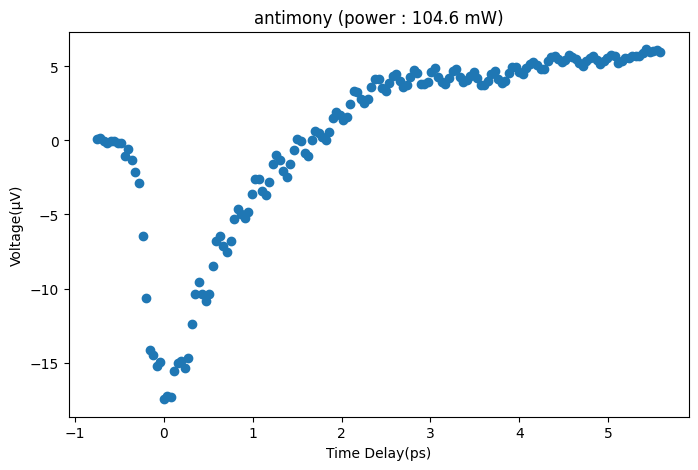

In [50]:
fig = plt.figure(figsize=(8,5))
plt.scatter(time, voltage)
plt.xlabel("Time Delay(ps)")
plt.ylabel(f"Voltage(\u00B5V)")
plt.title(f"{metal} (power : {power} mW)")

# fig.savefig(f"antimony_raw.pdf", dpi=300, bbox_inches="tight")

plt.show()